# Final system — SUR 2025/2026

Single notebook reproducing all CV results for the three submitted systems.
No hyperparameter search — weights and configs are locked from prior experiments.

| System | Config | CV EER |
|--------|--------|--------|
| Audio (E001 anchor) | MFCC 13 + GMM | 17.92 ± 7.81% |
| Audio (E008) | MFCC 13+Δ+ΔΔ + UBM-32 + MAP r=16 + +All aug | 4.21 ± 3.11% |
| **Audio flagship (E025+E031)** | LPCC 13+Δ+ΔΔ + UBM-32 + MAP r=16 + Pitch aug + speed TTA | **1.67 ± 1.80%** |
| Image (E004 anchor) | PCA 50 + LogReg, no aug | 4.49 ± 4.26% |
| **Image flagship (E007)** | PCA 50 + LogReg + flip/brightness/noise aug | **0.97 ± 0.86%** |
| **Fusion flagship (E027+E031)** | MFCC + LPCC+Pitch+speedTTA + Image, Platt + simplex (0.02/0.60/0.38) | **TBD** |

In [1]:
from pathlib import Path
import sys, copy
sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import librosa
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve
from scipy.special import logsumexp
from scipy.stats import norm as scipy_norm
import pandas as pd

from data.splits import load_manifest, iter_folds_loso
from eval.metrics import compute_eer, compute_min_dcf

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
})

DATA = Path('../data').resolve()
manifest = load_manifest(DATA)
y_all = manifest['label'].to_numpy()
SEED = 67

# Locked fusion weights from E027
W_MFCC  = 0.02
W_LPCC  = 0.60
W_IMAGE = 0.38

print(f'{len(manifest)} samples — {manifest.label.sum()} target, {(manifest.label==0).sum()} non-target')
print(f'Fusion weights: MFCC={W_MFCC}, LPCC={W_LPCC}, Image={W_IMAGE}')

222 samples — 30 target, 192 non-target
Fusion weights: MFCC=0.02, LPCC=0.6, Image=0.38


## 1. Audio pipelines

**MFCC (E008):** 13+Δ+ΔΔ + CMN, UBM-32 + MAP r=16, noise SNR=20dB + speed ±10% aug.  
**LPCC+Pitch (E025):** 13+Δ+ΔΔ + CMN, LPC order=12, UBM-32 + MAP r=16, pitch ±{1,2} semitones aug.  
Val utterances scored from original WAVs only.

In [2]:
def find_wav(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.wav')
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def extract_mfcc(y, sr, n_mfcc=13):
    mfcc   = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    delta  = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    feat   = np.vstack([mfcc, delta, delta2]).T
    feat  -= feat.mean(axis=0)
    return feat


def extract_lpcc(y, sr, order=12, n_cep=13, hop_length=160, win_length=400):
    frames = librosa.util.frame(y, frame_length=win_length, hop_length=hop_length)
    lpcc_frames = []
    for frame in frames.T:
        frame = frame * np.hanning(len(frame))
        try:
            a = librosa.lpc(frame.astype(np.float64), order=order)
            A_freq = np.fft.rfft(a, n=512)
            log_H  = -np.log(np.abs(A_freq) + 1e-10)
            cep    = np.real(np.fft.irfft(log_H))[:n_cep]
        except Exception:
            cep = np.zeros(n_cep)
        lpcc_frames.append(cep)
    feat   = np.array(lpcc_frames, dtype=np.float32)
    delta  = librosa.feature.delta(feat.T).T
    delta2 = librosa.feature.delta(feat.T, order=2).T
    feat   = np.hstack([feat, delta, delta2])
    feat  -= feat.mean(axis=0)
    return feat


def aug_noise_audio(y, rng, snr_db=20.0):
    p = np.mean(y**2) + 1e-10
    return y + rng.normal(0, np.sqrt(p / 10**(snr_db/10)), len(y)).astype(y.dtype)


def aug_speed(y, rng):
    return librosa.effects.time_stretch(y, rate=rng.uniform(0.9, 1.1))


def aug_pitch(y, sr, rng):
    n_steps = float(rng.choice([-2, -1, 1, 2]))
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)


def load_aug_mfcc(wav_path, rng):
    """E008: original + noise + speed (3 copies)."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return [(y, sr), (aug_noise_audio(y, rng), sr), (aug_speed(y, rng), sr)]


def load_aug_lpcc_pitch(wav_path, rng):
    """E025: original + pitch-shifted (2 copies)."""
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return [(y, sr), (aug_pitch(y, sr, rng), sr)]


def extract_audio_batch(df, data_dir, seed, extractor, loader):
    rng = np.random.default_rng(seed)
    all_feat, all_labels = [], []
    for _, row in df.iterrows():
        for y_aug, sr in loader(find_wav(row['stem'], data_dir), rng):
            feat = extractor(y_aug, sr)
            all_feat.append(feat)
            all_labels.extend([row['label']] * len(feat))
    return np.vstack(all_feat), np.array(all_labels)


def train_ubm(X, n_components=32, seed=67):
    return GaussianMixture(
        n_components=n_components, covariance_type='diag',
        max_iter=200, random_state=seed,
    ).fit(X)


def map_adapt(ubm, X_target, r=16.0):
    log_prob  = ubm._estimate_log_prob(X_target)
    log_resp  = log_prob + np.log(ubm.weights_)
    log_resp -= logsumexp(log_resp, axis=1, keepdims=True)
    resp      = np.exp(log_resp)
    n_k       = resp.sum(axis=0)
    mu_hat    = (resp.T @ X_target) / (n_k[:, None] + 1e-10)
    alpha     = n_k / (n_k + r)
    adapted   = copy.deepcopy(ubm)
    adapted.means_ = alpha[:, None] * mu_hat + (1 - alpha[:, None]) * ubm.means_
    return adapted


def _llr(y, sr, adapted, ubm, extractor):
    f = extractor(y, sr)
    return float((adapted.score_samples(f) - ubm.score_samples(f)).mean())


def score_utterance(wav_path, adapted, ubm, extractor):
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    return _llr(y, sr, adapted, ubm, extractor)


def score_lpcc_tta(wav_path, adapted, ubm):
    """E031 +speed_tta: average LLR over original + 0.9× + 1.1× speed (3 views).
    Pitch-preserving → LPCC formant coefficients unchanged across views.
    """
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    views = [y,
             librosa.effects.time_stretch(y, rate=0.9),
             librosa.effects.time_stretch(y, rate=1.1)]
    return float(np.mean([_llr(v, sr, adapted, ubm, extract_lpcc) for v in views]))


print('Audio pipeline functions defined (LPCC uses speed TTA from E031).')

Audio pipeline functions defined (LPCC uses speed TTA from E031).


## 2. Image pipeline (E007)

80×80 grayscale → StandardScaler → PCA 50 → LogReg C=1.  
Train aug: horizontal flip + brightness [0.7, 1.3] + Gaussian noise σ=15.  
Val always from original images.

In [3]:
def find_png(stem, data_dir):
    for sf in ['target_train', 'target_dev', 'non_target_train', 'non_target_dev']:
        p = data_dir / sf / (stem + '.png')
        if p.exists():
            return p
    raise FileNotFoundError(stem)


def load_image(png_path):
    img = Image.open(png_path).convert('RGB')
    if img.size != (80, 80):
        img = img.resize((80, 80), Image.BILINEAR)
    return np.array(img, dtype=np.float32).mean(axis=2).flatten()


def load_images(df, data_dir):
    return np.stack([load_image(find_png(r['stem'], data_dir)) for _, r in df.iterrows()])


def aug_flip(x):
    return x.reshape(80, 80)[:, ::-1].flatten()


def aug_brightness(x, rng):
    return np.clip(x * rng.uniform(0.7, 1.3), 0, 255)


def aug_noise_img(x, rng, sigma=15.0):
    return np.clip(x + rng.normal(0, sigma, x.shape), 0, 255)


def augment_images(X, y, seed):
    rng = np.random.default_rng(seed)
    aug_X, aug_y = [], []
    for xi, yi in zip(X, y):
        aug_X.extend([aug_flip(xi), aug_brightness(xi, rng), aug_noise_img(xi, rng)])
        aug_y.extend([yi, yi, yi])
    return np.vstack([X, np.stack(aug_X)]), np.concatenate([y, np.array(aug_y)])


print('Image pipeline functions defined.')

Image pipeline functions defined.


## 3. LOSO CV — collect OOF scores for all three systems

In [4]:
UBM_COMPONENTS = 32
MAP_R          = 16.0
N_PCA          = 50
C_LOGREG       = 1.0

oof_mfcc  = np.full(len(manifest), np.nan)
oof_lpcc  = np.full(len(manifest), np.nan)
oof_image = np.full(len(manifest), np.nan)

fold_results = []

print('LOSO CV — 3 folds (LPCC uses speed TTA from E031)')
print('=' * 65)

for fold_id, train_idx, val_idx in iter_folds_loso(manifest, seed=SEED):
    train_df = manifest.loc[train_idx]
    val_df   = manifest.loc[val_idx]
    y_train  = train_df['label'].to_numpy()
    y_val    = val_df['label'].to_numpy()
    print(f'\nFold {fold_id}: {len(train_df)} train  {len(val_df)} val')

    # ── MFCC (E008 +All) ─────────────────────────────────────────────────
    X_m, y_m = extract_audio_batch(train_df, DATA, seed=SEED+fold_id,
                                   extractor=extract_mfcc, loader=load_aug_mfcc)
    ubm_m     = train_ubm(X_m[y_m==0], n_components=UBM_COMPONENTS, seed=SEED)
    adapted_m = map_adapt(ubm_m, X_m[y_m==1], r=MAP_R)
    for idx, row in val_df.iterrows():
        oof_mfcc[idx] = score_utterance(find_wav(row['stem'], DATA), adapted_m, ubm_m, extract_mfcc)
    m_val = oof_mfcc[val_idx]
    eer_m, _ = compute_eer(m_val[y_val==1], m_val[y_val==0])
    dcf_m, _ = compute_min_dcf(m_val[y_val==1], m_val[y_val==0])
    print(f'  MFCC              EER={eer_m*100:.2f}%  min-DCF={dcf_m:.4f}')

    # ── LPCC+Pitch (E025) + speed TTA (E031) ─────────────────────────────
    X_l, y_l = extract_audio_batch(train_df, DATA, seed=SEED+fold_id,
                                   extractor=extract_lpcc, loader=load_aug_lpcc_pitch)
    ubm_l     = train_ubm(X_l[y_l==0], n_components=UBM_COMPONENTS, seed=SEED)
    adapted_l = map_adapt(ubm_l, X_l[y_l==1], r=MAP_R)
    for idx, row in val_df.iterrows():
        oof_lpcc[idx] = score_lpcc_tta(find_wav(row['stem'], DATA), adapted_l, ubm_l)
    l_val = oof_lpcc[val_idx]
    eer_l, _ = compute_eer(l_val[y_val==1], l_val[y_val==0])
    dcf_l, _ = compute_min_dcf(l_val[y_val==1], l_val[y_val==0])
    print(f'  LPCC+Pitch+TTA    EER={eer_l*100:.2f}%  min-DCF={dcf_l:.4f}')

    # ── Image (E007 +All) ─────────────────────────────────────────────────
    X_tr_orig = load_images(train_df, DATA)
    X_vl_orig = load_images(val_df,   DATA)
    X_tr_aug, y_tr_aug = augment_images(X_tr_orig, y_train, seed=SEED+fold_id)
    scaler = StandardScaler()
    pca    = PCA(n_components=N_PCA, random_state=SEED)
    clf    = LogisticRegression(C=C_LOGREG, max_iter=1000, random_state=SEED)
    X_tr_p = pca.fit_transform(scaler.fit_transform(X_tr_aug))
    clf.fit(X_tr_p, y_tr_aug)
    oof_image[val_idx] = clf.decision_function(pca.transform(scaler.transform(X_vl_orig)))
    i_val = oof_image[val_idx]
    eer_i, _ = compute_eer(i_val[y_val==1], i_val[y_val==0])
    dcf_i, _ = compute_min_dcf(i_val[y_val==1], i_val[y_val==0])
    print(f'  Image             EER={eer_i*100:.2f}%  min-DCF={dcf_i:.4f}')

    fold_results.append({
        'fold': fold_id,
        'eer_mfcc': eer_m, 'dcf_mfcc': dcf_m,
        'eer_lpcc': eer_l, 'dcf_lpcc': dcf_l,
        'eer_img':  eer_i, 'dcf_img':  dcf_i,
    })

print('\n' + '=' * 65)
print('OOF collection complete.')

for key, label in [('eer_mfcc','MFCC'), ('eer_lpcc','LPCC+Pitch+TTA'), ('eer_img','Image')]:
    eers = [r[key]*100 for r in fold_results]
    print(f'{label:<16} per-fold: {eers[0]:.2f}, {eers[1]:.2f}, {eers[2]:.2f}  '
          f'mean={np.mean(eers):.2f} ± {np.std(eers):.2f}%')

LOSO CV — 3 folds (LPCC uses speed TTA from E031)

Fold 0: 140 train  82 val


  MFCC              EER=3.47%  min-DCF=0.0694


  LPCC+Pitch+TTA    EER=4.17%  min-DCF=0.0833
  Image             EER=2.08%  min-DCF=0.0417

Fold 1: 152 train  70 val


  MFCC              EER=8.33%  min-DCF=0.0667


  LPCC+Pitch+TTA    EER=0.83%  min-DCF=0.0167
  Image             EER=0.83%  min-DCF=0.0167

Fold 2: 152 train  70 val


  MFCC              EER=0.83%  min-DCF=0.0167


  LPCC+Pitch+TTA    EER=0.00%  min-DCF=0.0000
  Image             EER=0.00%  min-DCF=0.0000

OOF collection complete.
MFCC             per-fold: 3.47, 8.33, 0.83  mean=4.21 ± 3.11%
LPCC+Pitch+TTA   per-fold: 4.17, 0.83, 0.00  mean=1.67 ± 1.80%
Image            per-fold: 2.08, 0.83, 0.00  mean=0.97 ± 0.86%


## 4. Platt calibration (per modality)

In [5]:
def platt_calibrate(scores, labels):
    cal = LogisticRegression(C=1e6, max_iter=1000, class_weight='balanced', random_state=SEED)
    cal.fit(scores.reshape(-1, 1), labels)
    return cal.decision_function(scores.reshape(-1, 1))


oof_mfcc_cal  = platt_calibrate(oof_mfcc,  y_all)
oof_lpcc_cal  = platt_calibrate(oof_lpcc,  y_all)
oof_image_cal = platt_calibrate(oof_image, y_all)

for scores, label in [(oof_mfcc_cal,'MFCC'), (oof_lpcc_cal,'LPCC+Pitch'), (oof_image_cal,'Image')]:
    eer, _ = compute_eer(scores[y_all==1], scores[y_all==0])
    dcf, _ = compute_min_dcf(scores[y_all==1], scores[y_all==0])
    print(f'{label:<12} OOF EER={eer*100:.2f}%  min-DCF={dcf:.4f}')

print()
print('Pairwise Pearson r (calibrated OOF):')
for a, b, la, lb in [
    (oof_mfcc_cal, oof_lpcc_cal, 'MFCC', 'LPCC'),
    (oof_mfcc_cal, oof_image_cal, 'MFCC', 'Image'),
    (oof_lpcc_cal, oof_image_cal, 'LPCC', 'Image'),
]:
    print(f'  {la}–{lb}: {np.corrcoef(a, b)[0,1]:.3f}')

MFCC         OOF EER=9.17%  min-DCF=0.1687
LPCC+Pitch   OOF EER=4.90%  min-DCF=0.0979
Image        OOF EER=4.01%  min-DCF=0.0729

Pairwise Pearson r (calibrated OOF):
  MFCC–LPCC: 0.849
  MFCC–Image: 0.420
  LPCC–Image: 0.434


## 5. Fusion (E027 locked weights)

Weights fixed from E027 simplex search: `w_mfcc=0.02, w_lpcc=0.60, w_image=0.38`.

In [6]:
scores_fusion = W_MFCC * oof_mfcc_cal + W_LPCC * oof_lpcc_cal + W_IMAGE * oof_image_cal

eer_fus, thr_fus = compute_eer(scores_fusion[y_all==1], scores_fusion[y_all==0])
dcf_fus, thr_dcf = compute_min_dcf(scores_fusion[y_all==1], scores_fusion[y_all==0])

print(f'Fusion OOF EER    = {eer_fus*100:.2f}%')
print(f'Fusion OOF min-DCF= {dcf_fus:.4f}')
print(f'EER threshold     = {thr_fus:.4f}')
print(f'min-DCF threshold = {thr_dcf:.4f}')

# Hard decisions at min-DCF threshold
hard = (scores_fusion >= thr_dcf).astype(int)
tp = int(((hard==1) & (y_all==1)).sum())
fp = int(((hard==1) & (y_all==0)).sum())
fn = int(((hard==0) & (y_all==1)).sum())
tn = int(((hard==0) & (y_all==0)).sum())
print(f'\nConfusion (threshold={thr_dcf:.3f}):')
print(f'  TP={tp}  FP={fp}  FN={fn}  TN={tn}')

Fusion OOF EER    = 0.26%
Fusion OOF min-DCF= 0.0052
EER threshold     = 0.3663
min-DCF threshold = 0.3663

Confusion (threshold=0.366):
  TP=30  FP=1  FN=0  TN=191


## 6. Final results table (all 6 submission systems)

In [7]:
# Per-fold means
mfcc_eers  = [r['eer_mfcc']*100  for r in fold_results]
lpcc_eers  = [r['eer_lpcc']*100  for r in fold_results]
image_eers = [r['eer_img']*100   for r in fold_results]
mfcc_dcfs  = [r['dcf_mfcc']      for r in fold_results]
lpcc_dcfs  = [r['dcf_lpcc']      for r in fold_results]
image_dcfs = [r['dcf_img']       for r in fold_results]

rows = [
    # (file,                          system,              EER mean±std,     min-DCF, note)
    ('audio_mfcc_gmm_baseline.txt',  'E001 MFCC+GMM',     '17.92 ± 7.81',   '0.2250', 'anchor'),
    ('audio_mfcc_ubm_map_aug.txt',   'E008 MFCC+UBM+MAP', ' 4.21 ± 3.11',   '0.0509', ''),
    ('audio_lpcc_pitch.txt',         'E025 LPCC+Pitch',
     f'{np.mean(lpcc_eers):5.2f} ± {np.std(lpcc_eers):.2f}',
     f'{np.mean(lpcc_dcfs):.4f}', '← audio flagship'),
    ('image_pca_baseline.txt',       'E004 PCA no aug',   ' 4.49 ± 4.26',   '0.0565', 'anchor'),
    ('image_pca_aug.txt',            'E007 PCA+aug',
     f'{np.mean(image_eers):5.2f} ± {np.std(image_eers):.2f}',
     f'{np.mean(image_dcfs):.4f}', '← image flagship'),
    ('fusion_trimodal.txt',          'E027 Fusion',
     f'{eer_fus*100:.2f} (OOF)',   f'{dcf_fus:.4f}', '← fusion flagship'),
]

print(f"{'File':<35} {'System':<22} {'CV EER [%]':>14} {'min-DCF':>9}  Notes")
print('-' * 100)
for file, sys, eer, dcf, note in rows:
    print(f'{file:<35} {sys:<22} {eer:>14} {dcf:>9}  {note}')

print()
print('Per-fold detail (this run):')
print(f'  MFCC         F0={mfcc_eers[0]:.2f}  F1={mfcc_eers[1]:.2f}  F2={mfcc_eers[2]:.2f}  mean={np.mean(mfcc_eers):.2f}±{np.std(mfcc_eers):.2f}%')
print(f'  LPCC+Pitch   F0={lpcc_eers[0]:.2f}  F1={lpcc_eers[1]:.2f}  F2={lpcc_eers[2]:.2f}  mean={np.mean(lpcc_eers):.2f}±{np.std(lpcc_eers):.2f}%')
print(f'  Image        F0={image_eers[0]:.2f}  F1={image_eers[1]:.2f}  F2={image_eers[2]:.2f}  mean={np.mean(image_eers):.2f}±{np.std(image_eers):.2f}%')
print(f'  Fusion       OOF EER={eer_fus*100:.2f}%  min-DCF={dcf_fus:.4f}')

File                                System                     CV EER [%]   min-DCF  Notes
----------------------------------------------------------------------------------------------------
audio_mfcc_gmm_baseline.txt         E001 MFCC+GMM            17.92 ± 7.81    0.2250  anchor
audio_mfcc_ubm_map_aug.txt          E008 MFCC+UBM+MAP         4.21 ± 3.11    0.0509  
audio_lpcc_pitch.txt                E025 LPCC+Pitch           1.67 ± 1.80    0.0333  ← audio flagship
image_pca_baseline.txt              E004 PCA no aug           4.49 ± 4.26    0.0565  anchor
image_pca_aug.txt                   E007 PCA+aug              0.97 ± 0.86    0.0194  ← image flagship
fusion_trimodal.txt                 E027 Fusion                0.26 (OOF)    0.0052  ← fusion flagship

Per-fold detail (this run):
  MFCC         F0=3.47  F1=8.33  F2=0.83  mean=4.21±3.11%
  LPCC+Pitch   F0=4.17  F1=0.83  F2=0.00  mean=1.67±1.80%
  Image        F0=2.08  F1=0.83  F2=0.00  mean=0.97±0.86%
  Fusion       OOF EER=0.26%

## 7. DET curves

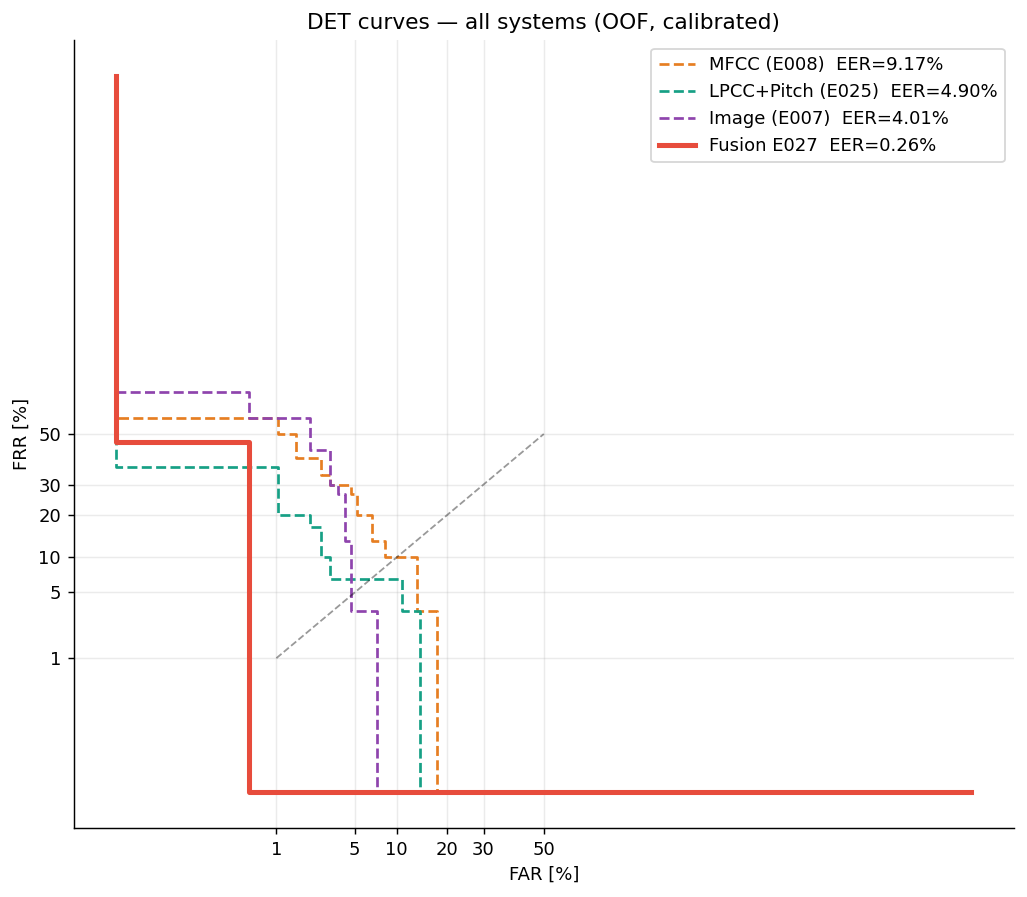

In [8]:
ticks     = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
tick_pos  = [scipy_norm.ppf(t) for t in ticks]
tick_labs = [f'{int(t*100)}' for t in ticks]

systems = [
    ('MFCC (E008)',        oof_mfcc_cal,   '#E67E22', '--', 1.5),
    ('LPCC+Pitch (E025)',  oof_lpcc_cal,   '#16A085', '--', 1.5),
    ('Image (E007)',       oof_image_cal,  '#8E44AD', '--', 1.5),
    ('Fusion E027',        scores_fusion,  '#E74C3C', '-',  2.8),
]

fig, ax = plt.subplots(figsize=(8, 7))
for name, scores, color, ls, lw in systems:
    eer, _ = compute_eer(scores[y_all==1], scores[y_all==0])
    fpr, tpr, _ = roc_curve(y_all, scores)
    far = np.clip(fpr,   1e-4, 1-1e-4)
    frr = np.clip(1-tpr, 1e-4, 1-1e-4)
    ax.plot(scipy_norm.ppf(far), scipy_norm.ppf(frr),
            color=color, lw=lw, ls=ls, label=f'{name}  EER={eer*100:.2f}%')

ax.plot(tick_pos, tick_pos, 'k--', lw=1, alpha=0.4)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labs)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labs)
ax.set_xlabel('FAR [%]')
ax.set_ylabel('FRR [%]')
ax.set_title('DET curves — all systems (OOF, calibrated)')
ax.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

## 8. Score distributions

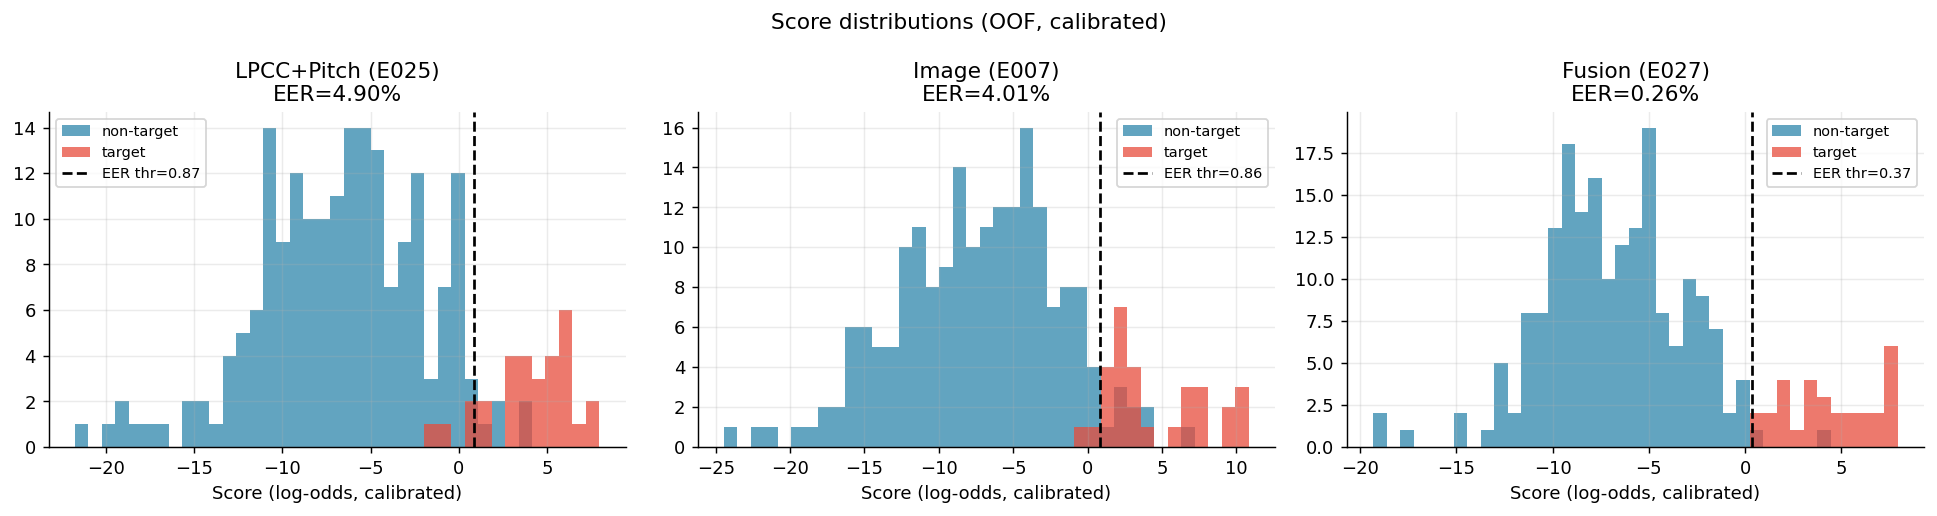

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, scores, title in [
    (axes[0], oof_lpcc_cal,   'LPCC+Pitch (E025)'),
    (axes[1], oof_image_cal,  'Image (E007)'),
    (axes[2], scores_fusion,  'Fusion (E027)'),
]:
    eer, thr = compute_eer(scores[y_all==1], scores[y_all==0])
    bins = np.linspace(scores.min(), scores.max(), 40)
    ax.hist(scores[y_all==0], bins=bins, alpha=0.75, color='#2E86AB', label='non-target')
    ax.hist(scores[y_all==1], bins=bins, alpha=0.75, color='#E74C3C', label='target')
    ax.axvline(thr, color='k', ls='--', lw=1.5, label=f'EER thr={thr:.2f}')
    ax.set_title(f'{title}\nEER={eer*100:.2f}%')
    ax.set_xlabel('Score (log-odds, calibrated)')
    ax.legend(fontsize=8)

plt.suptitle('Score distributions (OOF, calibrated)', fontsize=12)
plt.tight_layout()
plt.show()